# Modelo Principal — LightGBM

**Objetivo:** superar el baseline (ROC-AUC 0.7435, Recall 0.6707) usando LightGBM.

**¿Por qué LightGBM sobre otros modelos?**
- Maneja variables categóricas nativo (sin necesidad de encoding manual)
- Maneja NaN nativo (sin necesidad de imputer explícito)
- Captura relaciones no lineales e interacciones entre variables
- Es el estándar de la industria en competencias de tabular data (Kaggle)
- Rápido incluso en datasets de 300k+ filas

**Referencia baseline:**
- ROC-AUC: 0.7435
- Recall:   0.6707
- Precision: 0.1587

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, classification_report,
    RocCurveDisplay, ConfusionMatrixDisplay,
    confusion_matrix, precision_score, recall_score, f1_score
)

pd.set_option('display.max_columns', 100)
RANDOM_STATE = 42
DATA_PATH = '../data/raw/application_train.csv'

# Métricas del baseline para comparar al final
BASELINE_AUC    = 0.7435
BASELINE_RECALL = 0.6707

## 1. Preprocesamiento — igual que baseline pero sin encoding manual

LightGBM acepta variables categóricas directamente si las marcamos con dtype `category`.
Tampoco necesita imputer — maneja NaN internamente durante el entrenamiento.
Esto simplifica el pipeline y evita pérdida de información por imputación.

In [2]:
df = pd.read_csv(DATA_PATH)
print(f'Shape original: {df.shape}')

Shape original: (307511, 122)


In [3]:
# Eliminar columnas con >40% missings (misma regla que baseline)
missing_pct = df.isnull().mean()
cols_to_drop = missing_pct[missing_pct > 0.4].index.tolist()
df = df.drop(columns=cols_to_drop)
print(f'Columnas eliminadas por >40% missings: {len(cols_to_drop)}')

# Transformaciones del EDA
df['AGE_YEARS'] = df['DAYS_BIRTH'].abs() / 365
df = df.drop(columns=['DAYS_BIRTH'])

df['FLAG_EMPLOYED_ANOMALY'] = (df['DAYS_EMPLOYED'] == 365243).astype(int)
df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)

df = df.drop(columns=['SK_ID_CURR'])

# Marcar categóricas como dtype 'category' — LightGBM las maneja nativo
cat_cols = df.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    df[col] = df[col].astype('category')

print(f'Variables categóricas (dtype category): {len(cat_cols)}')
print(f'Shape final: {df.shape}')

Columnas eliminadas por >40% missings: 49
Variables categóricas (dtype category): 12
Shape final: (307511, 73)


## 2. Split train/test

In [4]:
X = df.drop(columns=['TARGET'])
y = df['TARGET']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

# Calcular scale_pos_weight: ratio entre clase negativa y positiva
# Le dice a LightGBM cuánto pesar los incumplimientos
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

print(f'Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}')
print(f'Incumplimientos en train: {pos:,} | No incumplimientos: {neg:,}')
print(f'scale_pos_weight: {scale_pos_weight:.2f} (cada incumplimiento pesa {scale_pos_weight:.1f}x más)')

Train: 246,008 | Test: 61,503
Incumplimientos en train: 19,860 | No incumplimientos: 226,148
scale_pos_weight: 11.39 (cada incumplimiento pesa 11.4x más)


## 3. Entrenamiento LightGBM

Usamos parámetros conservadores para un primer entrenamiento limpio.
No hacemos hyperparameter tuning todavía — queremos ver el valor base del modelo.

**Parámetros clave:**
- `n_estimators=1000`: máximo de árboles — usamos early stopping para parar antes
- `early_stopping_rounds=50`: para si 50 rondas seguidas no mejora en validación
- `learning_rate=0.05`: paso pequeño = aprendizaje más estable
- `num_leaves=31`: complejidad de cada árbol (31 es el default conservador)
- `scale_pos_weight`: compensa el desbalance de clases

In [5]:
model = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    scale_pos_weight=scale_pos_weight,
    metric='auc',               # métrica interna que LightGBM optimiza
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1
)

print('Entrenando LightGBM con early stopping sobre AUC...')
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=True),
        lgb.log_evaluation(period=100)
    ]
)
print(f'\nÁrboles usados: {model.best_iteration_}')

Entrenando LightGBM con early stopping sobre AUC...
Training until validation scores don't improve for 50 rounds
[100]	valid_0's auc: 0.753176
[200]	valid_0's auc: 0.755528
[300]	valid_0's auc: 0.755867
Early stopping, best iteration is:
[345]	valid_0's auc: 0.75611

Árboles usados: 345


## 4. Evaluación y comparación con baseline

In [6]:
y_proba = model.predict_proba(X_test)[:, 1]

# Umbral de decisión: 0.5 por defecto
# Con desbalance, a veces conviene ajustarlo — lo exploraremos
threshold = 0.5
y_pred = (y_proba >= threshold).astype(int)

roc_auc = roc_auc_score(y_test, y_proba)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print('=' * 55)
print(f'  {"Métrica":<15} {"Baseline":>10} {"LightGBM":>10} {"Δ":>8}')
print('=' * 55)
print(f'  {"ROC-AUC":<15} {BASELINE_AUC:>10.4f} {roc_auc:>10.4f} {roc_auc-BASELINE_AUC:>+8.4f}')
print(f'  {"Recall":<15} {BASELINE_RECALL:>10.4f} {recall:>10.4f} {recall-BASELINE_RECALL:>+8.4f}')
print('=' * 55)
print()
print(classification_report(y_test, y_pred, target_names=['No incumple', 'Incumple']))

  Métrica           Baseline   LightGBM        Δ
  ROC-AUC             0.7435     0.7561  +0.0126
  Recall              0.6707     0.6602  -0.0105

              precision    recall  f1-score   support

 No incumple       0.96      0.72      0.82     56538
    Incumple       0.17      0.66      0.27      4965

    accuracy                           0.71     61503
   macro avg       0.57      0.69      0.55     61503
weighted avg       0.90      0.71      0.78     61503



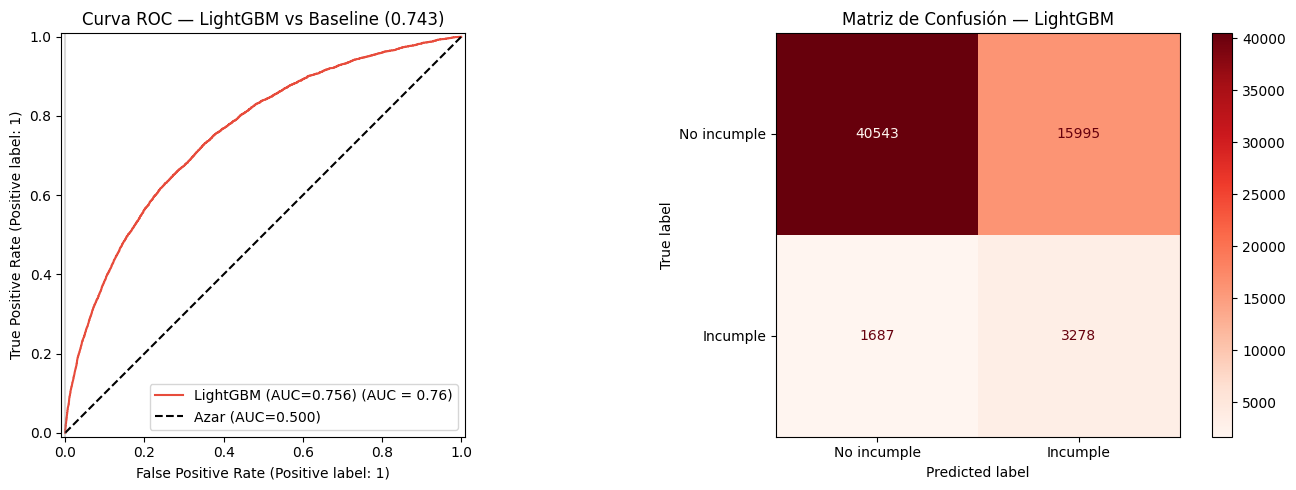

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

RocCurveDisplay.from_predictions(
    y_test, y_proba,
    name=f'LightGBM (AUC={roc_auc:.3f})',
    ax=axes[0], color='#e74c3c'
)
axes[0].plot([0, 1], [0, 1], 'k--', label='Azar (AUC=0.500)')
axes[0].axvline(0, color='gray', alpha=0.3)
# Línea de referencia del baseline
axes[0].set_title(f'Curva ROC — LightGBM vs Baseline (0.743)')
axes[0].legend()

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['No incumple', 'Incumple'],
    cmap='Reds',
    ax=axes[1]
)
axes[1].set_title('Matriz de Confusión — LightGBM')

plt.tight_layout()
plt.show()

## 5. Análisis del umbral de decisión

El umbral 0.5 no es necesariamente el mejor con clases desbalanceadas.
Exploramos cómo cambian precision y recall al ajustar el umbral.
El banco puede elegir según su apetito de riesgo.

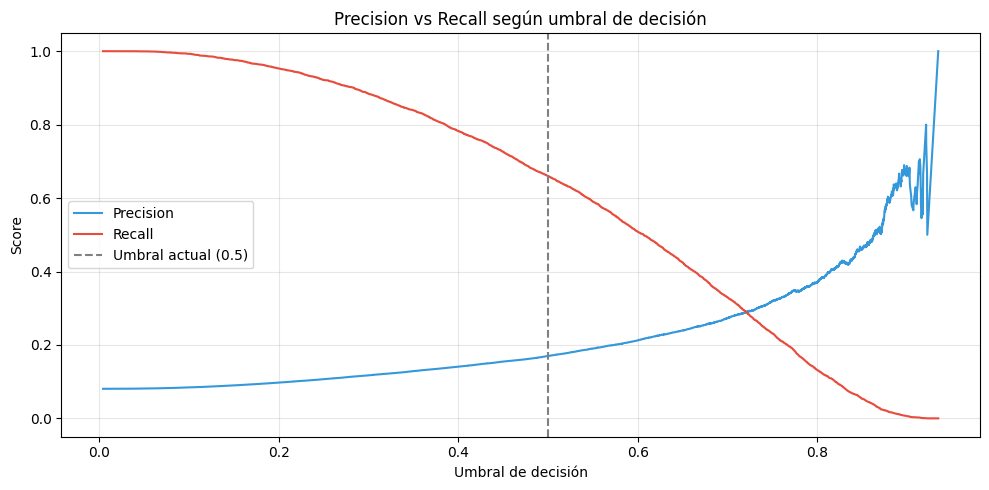

Umbral que maximiza F1: 0.645
  Precision en ese umbral: 0.2372
  Recall en ese umbral:    0.4359
  F1 en ese umbral:        0.3072


In [8]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, precisions[:-1], label='Precision', color='#3498db')
ax.plot(thresholds, recalls[:-1], label='Recall', color='#e74c3c')
ax.axvline(0.5, color='gray', linestyle='--', label='Umbral actual (0.5)')
ax.set_xlabel('Umbral de decisión')
ax.set_ylabel('Score')
ax.set_title('Precision vs Recall según umbral de decisión')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Encontrar umbral que maximiza F1
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-8)
best_threshold_idx = f1_scores.argmax()
best_threshold = thresholds[best_threshold_idx]
print(f'Umbral que maximiza F1: {best_threshold:.3f}')
print(f'  Precision en ese umbral: {precisions[best_threshold_idx]:.4f}')
print(f'  Recall en ese umbral:    {recalls[best_threshold_idx]:.4f}')
print(f'  F1 en ese umbral:        {f1_scores[best_threshold_idx]:.4f}')

## 6. Feature Importance — ¿qué variables usa el modelo?

LightGBM calcula la importancia de cada feature según cuántas veces se usó
para dividir los árboles (gain). Esto nos da una primera vista de qué variables
importan — luego lo profundizaremos con SHAP.

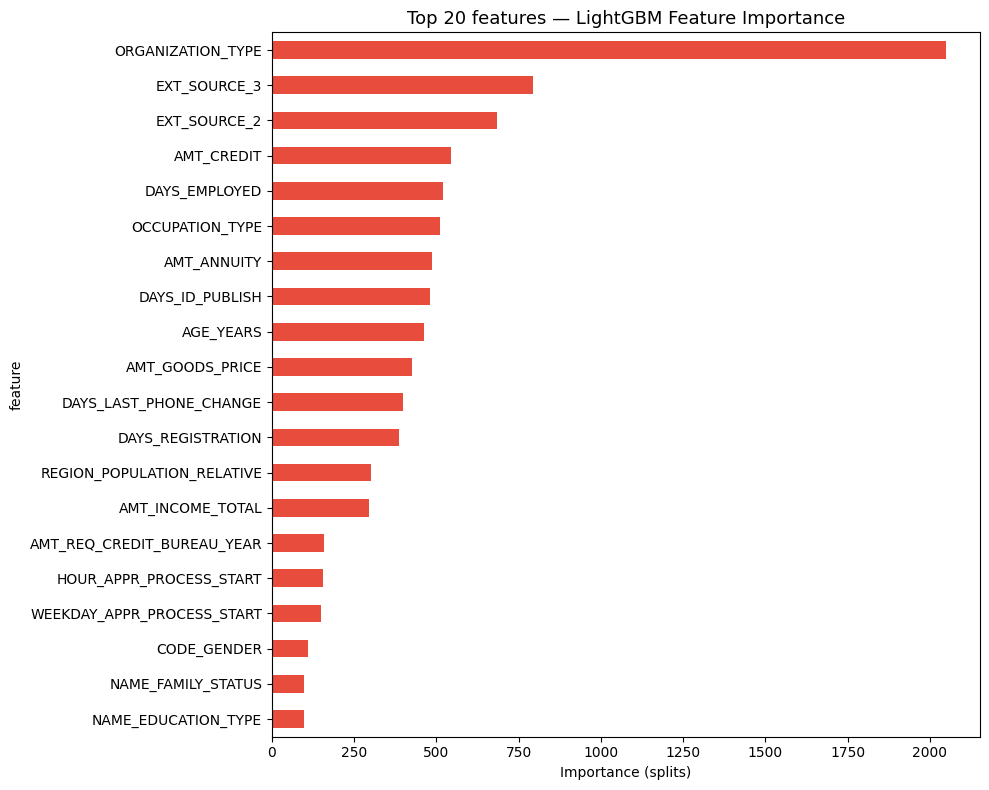

Top 10 features:
          feature  importance
ORGANIZATION_TYPE        2050
     EXT_SOURCE_3         793
     EXT_SOURCE_2         683
       AMT_CREDIT         545
    DAYS_EMPLOYED         519
  OCCUPATION_TYPE         510
      AMT_ANNUITY         488
  DAYS_ID_PUBLISH         482
        AGE_YEARS         462
  AMT_GOODS_PRICE         426


In [9]:
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
importance_df.head(20).sort_values('importance').plot(
    kind='barh', x='feature', y='importance',
    ax=ax, color='#e74c3c', legend=False
)
ax.set_title('Top 20 features — LightGBM Feature Importance', fontsize=13)
ax.set_xlabel('Importance (splits)')
plt.tight_layout()
plt.show()

print('Top 10 features:')
print(importance_df.head(10).to_string(index=False))

## 7. Resumen final y comparación

In [10]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

print('=== RESUMEN LIGHTGBM (Fase A — tabla principal) ===')
print(f'Árboles entrenados: {model.best_iteration_}')
print(f'Features:           {X_train.shape[1]}')
print()
print(f'  {"Métrica":<15} {"Baseline":>10} {"LightGBM":>10} {"Mejora":>8}')
print(f'  {"-"*43}')
print(f'  {"ROC-AUC":<15} {BASELINE_AUC:>10.4f} {roc_auc:>10.4f} {roc_auc-BASELINE_AUC:>+8.4f}')
print(f'  {"Recall":<15} {BASELINE_RECALL:>10.4f} {recall:>10.4f} {recall-BASELINE_RECALL:>+8.4f}')
print()
print(f'Análisis de errores:')
print(f'  De {fn+tp:,} incumplimientos reales, detectamos {tp:,} ({tp/(fn+tp)*100:.1f}%)')
print(f'  Nos escaparon {fn:,} incumplimientos ({fn/(fn+tp)*100:.1f}%)')
print(f'  Falsos positivos (buenos clientes rechazados): {fp:,}')
print()
print('Siguiente paso: SHAP para interpretabilidad')
print('Fase B:         feature engineering relacional desde tablas secundarias')

=== RESUMEN LIGHTGBM (Fase A — tabla principal) ===
Árboles entrenados: 345
Features:           72

  Métrica           Baseline   LightGBM   Mejora
  -------------------------------------------
  ROC-AUC             0.7435     0.7561  +0.0126
  Recall              0.6707     0.6602  -0.0105

Análisis de errores:
  De 4,965 incumplimientos reales, detectamos 3,278 (66.0%)
  Nos escaparon 1,687 incumplimientos (34.0%)
  Falsos positivos (buenos clientes rechazados): 15,995

Siguiente paso: SHAP para interpretabilidad
Fase B:         feature engineering relacional desde tablas secundarias
